# Differential Kinematics for the myCobot 280 Labs
## Lab 4: Jacobian Computation, Singularity Analysis, and Manipulability

Run this notebook from `~/venvs/mycobot`:

```bash
source ~/venvs/mycobot/bin/activate
jupyter lab
```

This lab continues Labs 1–3. You will compute the geometric Jacobian for the myCobot 280, explore how joint velocities map to Cartesian twists, analyse singularities, and compute manipulability measures. A final section bridges to the live `/mycobot/joint_velocity` topic.

All offline work in this notebook uses metres, radians, and rad/s. Only the live `/mycobot/ee_pose` topic uses mm and degrees.

In [22]:
# Locate the existing lab files and ROS description package.
import os
import sys
from pathlib import Path
from xacrodoc import packages

workspace_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'src/mycobot_description/package.xml').is_file()
)
packages.update_package_cache({
    'mycobot_description': str(workspace_root / 'src/mycobot_description')
})
# Original lab cells use os.getcwd() for the URDF and import helperFunctions.
os.chdir(workspace_root / 'notebooks')
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))


In [23]:
%matplotlib widget
import os
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

from spatialmath import SE3
from helperFunctions import (
    rpy_to_rot, rpy_to_transform, rot_to_vec,
    poseError, calculate_poseerror, transform_to_pipi,
)

np.set_printoptions(precision=4)

## Setup

### 1. Import the myCobot 280 URDF model

Load the URDF model distributed alongside this notebook. The kinematic chain of interest runs from `g_base` to `joint6_flange`. Inspect the model structure and link names.

In [24]:
notebook_path = os.getcwd()
mycobot_urdf_path = os.path.join(notebook_path, 'mycobot_280_gazebo.urdf')
mycobot = rtb.Robot.URDF(mycobot_urdf_path)
print(mycobot)

for link in mycobot.links:
    print(link.name)

ERobot: mycobot_280_gazebo, 6 joints (RRRRRR), dynamics, geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ world          │       │ BASE   │ SE3()                                               │
│    1 │ g_base         │       │ world  │ SE3()                                               │
│    2 │ joint1         │       │ g_base │ SE3()                                               │
│    3 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    4 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    5 │ joint4         │     2 │ joint3 │ SE3(-0.1104, 0, 0) ⊕ Rz(q2)                         │
│    6 │ joint5         │     3 │ joint4 │ SE3(-0.

/tmp/ipykernel_10244/2264729833.py:3: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  mycobot = rtb.Robot.URDF(mycobot_urdf_path)


### 2. Define a reference configuration

Choose a non-singular reference configuration for the myCobot 280 that keeps the arm away from joint limits and mechanical singularities. This configuration will be reused throughout the lab.

In [25]:
bodyname = 'joint6_flange'

# Reference configuration (radians) — away from singular stretched-out poses
q_ref = np.array([0.0, -np.pi/4, -np.pi/4, 0.0, np.pi/6, 0.0])

# Verify with FK
T_ref = mycobot.fkine(q_ref, end=bodyname)
print('Reference EE pose:\n', T_ref)
print('EE position (m):', T_ref.A[:3, 3])

Reference EE pose:
   -3.181e-06 -1        -1.837e-06  0.2472    
  -0.866     1.837e-06  0.5      -0.04082   
  -0.5       3.181e-06 -0.866     0.1771    
   0         0         0         1         

EE position (m): [ 0.2472 -0.0408  0.1771]


## The Geometric Jacobian

The geometric Jacobian $\boldsymbol{J}(\boldsymbol{q})$ maps joint velocities to the end-effector spatial velocity (twist):

$$\boldsymbol{v} = \begin{bmatrix} \dot{\boldsymbol{p}} \\ \boldsymbol{\omega} \end{bmatrix} = \boldsymbol{J}(\boldsymbol{q}) \, \dot{\boldsymbol{q}}$$

For the myCobot 280 with six revolute joints, $\boldsymbol{J}$ is a $6 \times 6$ matrix.

### 3. Compute the base-frame Jacobian

Compute the geometric Jacobian at the reference configuration using `robot.jacob0(q, end=bodyname)`. This gives the Jacobian expressed in the base frame (`g_base`). Inspect its shape and values.

In [26]:
J0 = mycobot.jacob0(q_ref, end=bodyname)  # base-frame geometric Jacobian at q_ref
print('J0 shape:', J0.shape)
print('J0:\n', J0)

J0 shape: (6, 6)
J0:
 [[ 4.0821e-02 -3.8574e-02  3.9491e-02  3.9491e-02  1.4506e-07  0.0000e+00]
 [ 2.4724e-01 -7.6649e-07 -7.6649e-07 -4.1386e-07  3.9491e-02  0.0000e+00]
 [ 1.3878e-17  2.4724e-01  1.6918e-01  7.3180e-02  2.2800e-02  0.0000e+00]
 [ 6.0394e-17 -3.6732e-06 -3.6732e-06 -3.6732e-06  1.0000e+00 -1.8366e-06]
 [ 5.5511e-17 -1.0000e+00 -1.0000e+00 -1.0000e+00 -3.6732e-06  5.0001e-01]
 [ 1.0000e+00 -3.6732e-06 -3.6732e-06 -3.6732e-06  1.3232e-16 -8.6602e-01]]


### 4. How the myCobot 280 controller builds the Jacobian

The `mycobot_control` codebase computes the Jacobian inside `_fk_and_jacobian(q)` by walking the URDF chain from `g_base` to `joint6_flange`. For each revolute joint $i$:

1. Apply the fixed frame offset: $\boldsymbol{T} = \boldsymbol{T} \cdot \boldsymbol{H}(\texttt{origin\_xyz}, \texttt{origin\_rpy})$
2. Record the joint position $\boldsymbol{p}_i = \boldsymbol{T}_{0:3, 3}$ and the world-frame axis $\boldsymbol{z}_i = \boldsymbol{R} \cdot \texttt{axis\_local}$
3. Apply the joint rotation: $\boldsymbol{T} = \boldsymbol{T} \cdot \boldsymbol{R}(\texttt{axis}, q_i)$

After the full chain, the end-effector position is $\boldsymbol{p}_e = \boldsymbol{T}_{0:3, 3}$. Each Jacobian column is then:

$$\boldsymbol{J}_i = \begin{bmatrix} \boldsymbol{z}_i \times (\boldsymbol{p}_e - \boldsymbol{p}_i) \\ \boldsymbol{z}_i \end{bmatrix}$$

where the top three rows are the linear velocity contribution and the bottom three are the angular velocity contribution. This is the standard geometric Jacobian construction for revolute joints.

### 5. Verify Jacobian column structure

Verify the structure above by checking that one column of your Jacobian matches the cross-product formula. Extract the joint axis and position for joint 1 and compute the expected Jacobian column manually.

In [27]:
# Extract the FK and verify one Jacobian column manually
T_ee = mycobot.fkine(q_ref, end=bodyname).A
p_ee = T_ee[:3, 3]

# For joint 1: get its world-frame axis and position
# Hint: determine the first joint axis from the myCobot URDF and express it in the world frame
# Determine the joint-axis direction and joint position at q_ref in the world frame
z_1 = mycobot.fkine(q_ref, end=next(link for link in mycobot.links if link.isjoint and link.jindex == 0)).A[:3, 2]  # world-frame axis of joint 1
p_1 = mycobot.fkine(q_ref, end=next(link for link in mycobot.links if link.isjoint and link.jindex == 0)).A[:3, 3]  # world-frame position of joint 1

J_col1_linear = np.cross(z_1, p_ee - p_1)  # compute the linear Jacobian component from the joint axis and lever arm
J_col1_angular = z_1  # compute the angular Jacobian component

print('Manual J column 1 (linear):', J_col1_linear)
print('Manual J column 1 (angular):', J_col1_angular)
print('jacob0 column 1:', J0[:, 0])

Manual J column 1 (linear): [ 0.0408  0.2472 -0.    ]
Manual J column 1 (angular): [0. 0. 1.]
jacob0 column 1: [4.0821e-02 2.4724e-01 1.3878e-17 6.0394e-17 5.5511e-17 1.0000e+00]


## Joint Velocities to Cartesian Twist

### 6. Map a joint velocity vector to a Cartesian twist

Given an arbitrary joint velocity vector $\dot{\boldsymbol{q}}$, compute the resulting Cartesian twist $\boldsymbol{v} = \boldsymbol{J}(\boldsymbol{q}) \, \dot{\boldsymbol{q}}$ at the reference configuration. Interpret the linear and angular components.

In [28]:
qdot = np.array([0.1, -0.2, 0.15, 0.0, 0.1, -0.05])  # rad/s

twist = J0 @ qdot  # compute the resulting end-effector twist

print('Linear velocity (m/s):', twist[:3])
print('Angular velocity (rad/s):', twist[3:])

Linear velocity (m/s): [ 0.0177  0.0287 -0.0218]
Angular velocity (rad/s): [0.1    0.025  0.1433]


### 7. Map a desired Cartesian twist to joint velocities

Given a desired end-effector twist, compute the required joint velocities using the Jacobian inverse. This is the resolved-rate equation:

$$\dot{\boldsymbol{q}} = \boldsymbol{J}(\boldsymbol{q})^{-1} \, \boldsymbol{v}_d$$

Since the myCobot 280 has a square $6 \times 6$ Jacobian (6 joints, 6 DOF task space), the inverse exists whenever the Jacobian is full rank.

In [29]:
# Desired Cartesian twist: small linear motion + small rotation
v_desired = np.array([0.05, 0.02, 0.0, 0.0, 0.0, 0.1])  # [vx, vy, vz, wx, wy, wz]

qdot_resolved = np.linalg.solve(J0, v_desired)  # solve the differential-kinematics equation for the joint rates

print('Required joint velocities (rad/s):', qdot_resolved)

Required joint velocities (rad/s): [ 8.0892e-02 -6.0378e-01  1.1032e+00 -5.1042e-01 -8.1044e-08 -2.2064e-02]


## Base-Frame vs End-Effector-Frame Jacobian

### 8. Compute the end-effector-frame Jacobian

The Jacobian can also be expressed in the end-effector frame. The relationship is:

$$\boldsymbol{J}_e = \begin{bmatrix} \boldsymbol{R}^T & \boldsymbol{0} \\ \boldsymbol{0} & \boldsymbol{R}^T \end{bmatrix} \boldsymbol{J}_0$$

where $\boldsymbol{R}$ is the rotation part of the end-effector transform. Compute $\boldsymbol{J}_e$ and compare it with `robot.jacobe(q, end=bodyname)`.

In [30]:
R_ee = T_ee[:3, :3]

# Build the 6x6 block-diagonal rotation transform
T_block = np.zeros((6, 6))
T_block[:3, :3] = R_ee.T  # insert the appropriate rotation between the two frames
T_block[3:, 3:] = R_ee.T  # insert the appropriate rotation between the two frames

J_ee_manual = T_block @ J0  # transform the Jacobian into the end-effector frame

# Compare with toolbox
J_ee_toolbox = mycobot.jacobe(q_ref, end=bodyname)  # compute the end-effector-frame Jacobian with the toolbox for comparison

print('Manual Je:\n', J_ee_manual)
print('Toolbox Je:\n', J_ee_toolbox)
print('Match:', np.allclose(J_ee_manual, J_ee_toolbox))

Manual Je:
 [[-2.1412e-01 -1.2362e-01 -8.4591e-02 -3.6590e-02 -4.5600e-02  0.0000e+00]
 [-4.0820e-02  3.8574e-02 -3.9490e-02 -3.9491e-02 -5.6144e-19  0.0000e+00]
 [ 1.2362e-01 -2.1412e-01 -1.4651e-01 -6.3376e-02  7.6271e-18  0.0000e+00]
 [-5.0001e-01  8.6602e-01  8.6602e-01  8.6602e-01 -2.3229e-17 -1.5086e-16]
 [ 3.1811e-06  1.8366e-06  1.8366e-06  1.8366e-06 -1.0000e+00  1.6299e-17]
 [-8.6602e-01 -5.0000e-01 -5.0000e-01 -5.0000e-01 -3.6732e-06  1.0000e+00]]
Toolbox Je:
 [[-2.1412e-01 -1.2362e-01 -8.4591e-02 -3.6590e-02 -4.5600e-02  0.0000e+00]
 [-4.0820e-02  3.8574e-02 -3.9490e-02 -3.9491e-02 -0.0000e+00  0.0000e+00]
 [ 1.2362e-01 -2.1412e-01 -1.4651e-01 -6.3376e-02  0.0000e+00  0.0000e+00]
 [-5.0001e-01  8.6602e-01  8.6602e-01  8.6602e-01  0.0000e+00  0.0000e+00]
 [ 3.1811e-06  1.8366e-06  1.8366e-06  1.8366e-06 -1.0000e+00  0.0000e+00]
 [-8.6602e-01 -5.0000e-01 -5.0000e-01 -5.0000e-01 -3.6732e-06  1.0000e+00]]
Match: True


## Singularity Analysis

A kinematic singularity occurs when the Jacobian loses rank, meaning certain end-effector motions become impossible regardless of joint velocities. For the myCobot 280, singularities typically occur:

- When the arm is fully extended (wrist near workspace boundary)
- When joint axes align (e.g., shoulder and elbow axes parallel)

### 9. Rank and determinant at the reference configuration

Compute the rank and determinant of the Jacobian at the reference configuration. A full-rank Jacobian (rank 6) with a non-zero determinant indicates a non-singular configuration.

In [31]:
rank_ref = np.linalg.matrix_rank(J0)  # compute the Jacobian rank
det_ref = np.linalg.det(J0)  # compute the Jacobian determinant

print(f'Rank at q_ref: {rank_ref}')
print(f'Determinant at q_ref: {det_ref:.6e}')

Rank at q_ref: 6
Determinant at q_ref: -1.604657e-03


### 10. Singular value decomposition

The singular values of the Jacobian reveal how close the configuration is to a singularity. The smallest singular value approaching zero signals a near-singular configuration.

In [32]:
U, sigma, Vt = np.linalg.svd(J0)

print('Singular values:', sigma)
print('Smallest singular value:', sigma[-1])
print('Condition number:', sigma[0] / sigma[-1])

Singular values: [1.8534 1.296  1.001  0.1773 0.1248 0.0302]
Smallest singular value: 0.03015968271672367
Condition number: 61.45248220794279


### 11. Find a singular configuration

Move the myCobot 280 toward a singular configuration (e.g., fully stretched out with joints 2 and 3 near zero). Compute the Jacobian, its rank, determinant, and singular values. Compare with the reference configuration.

In [33]:
# Near-singular: arm stretched out
q_singular = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

J_singular = mycobot.jacob0(q_singular, end=bodyname)  # compute the base-frame Jacobian at the near-singular configuration
rank_singular = np.linalg.matrix_rank(J_singular)
det_singular = np.linalg.det(J_singular)
_, sigma_singular, _ = np.linalg.svd(J_singular)

print(f'Rank at q_singular: {rank_singular}')
print(f'Determinant at q_singular: {det_singular:.6e}')
print('Singular values:', sigma_singular)
print('Smallest singular value:', sigma_singular[-1])

Rank at q_singular: 5
Determinant at q_singular: -2.059192e-25
Singular values: [1.7601e+00 1.4163e+00 1.0000e+00 1.5049e-01 1.8146e-07 1.5294e-17]
Smallest singular value: 1.5293919831349292e-17


### 12. Sweep one joint and track the smallest singular value

Sweep joint 2 from $-\pi$ to $\pi$ while keeping all other joints at zero. Plot the smallest singular value of the Jacobian as a function of $\theta_2$. Identify the configurations where the smallest singular value dips closest to zero.

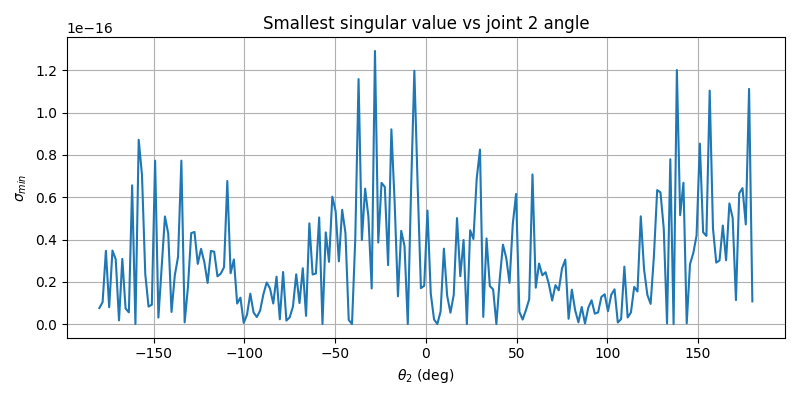

In [34]:
theta2_range = np.linspace(-np.pi, np.pi, 200)
sigma_min_sweep = np.zeros_like(theta2_range)

for i, th2 in enumerate(theta2_range):
    q_sweep = np.array([0.0, th2, 0.0, 0.0, 0.0, 0.0])
    J_sweep = mycobot.jacob0(q_sweep, end=bodyname)  # compute the base-frame Jacobian at the current sweep configuration
    _, sv, _ = np.linalg.svd(J_sweep)
    sigma_min_sweep[i] = sv[-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(theta2_range), sigma_min_sweep)
ax.set_xlabel(r'$\theta_2$ (deg)')
ax.set_ylabel(r'$\sigma_{min}$')
ax.set_title('Smallest singular value vs joint 2 angle')
ax.grid(True)
plt.tight_layout()

## Manipulability

### 13. Yoshikawa manipulability measure

The Yoshikawa manipulability index quantifies how well the robot can move in all directions at a given configuration:

$$w(\boldsymbol{q}) = \sqrt{\det\!\left(\boldsymbol{J}(\boldsymbol{q})\,\boldsymbol{J}(\boldsymbol{q})^T\right)}$$

For a square Jacobian this simplifies to $w = |\det(\boldsymbol{J})|$. Compute the manipulability at the reference and singular configurations.

In [35]:
w_ref = abs(np.linalg.det(J0))  # compute the manipulability measure at q_ref
w_singular = abs(np.linalg.det(J_singular))  # compute the manipulability measure at the near-singular configuration

print(f'Manipulability at q_ref: {w_ref:.6e}')
print(f'Manipulability at q_singular: {w_singular:.6e}')

Manipulability at q_ref: 1.604657e-03
Manipulability at q_singular: 2.059192e-25


### 14. Manipulability sweep

Sweep joint 2 as in Task 12 and plot the manipulability measure alongside the smallest singular value. Verify that manipulability drops to near zero at the same configurations where the smallest singular value vanishes.

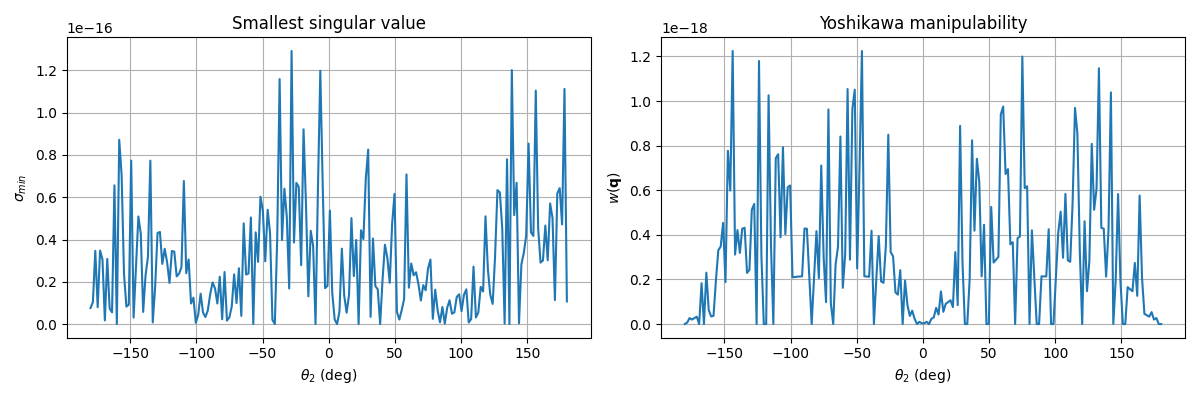

In [36]:
w_sweep = np.zeros_like(theta2_range)

for i, th2 in enumerate(theta2_range):
    q_sweep = np.array([0.0, th2, 0.0, 0.0, 0.0, 0.0])
    J_sweep = mycobot.jacob0(q_sweep, end=bodyname)  # compute the base-frame Jacobian at the current sweep configuration
    w_sweep[i] = abs(np.linalg.det(J_sweep))  # compute the manipulability measure for this configuration

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.degrees(theta2_range), sigma_min_sweep)
axes[0].set_xlabel(r'$\theta_2$ (deg)')
axes[0].set_ylabel(r'$\sigma_{min}$')
axes[0].set_title('Smallest singular value')
axes[0].grid(True)

axes[1].plot(np.degrees(theta2_range), w_sweep)
axes[1].set_xlabel(r'$\theta_2$ (deg)')
axes[1].set_ylabel(r'$w(\mathbf{q})$')
axes[1].set_title('Yoshikawa manipulability')
axes[1].grid(True)

plt.tight_layout()

### 15. Manipulability ellipsoid

The manipulability ellipsoid at a configuration $\boldsymbol{q}$ is defined by $\boldsymbol{J}\boldsymbol{J}^T$. Its principal axes correspond to the singular vectors, and their lengths are the singular values. Visualise the linear-velocity part of the ellipsoid (top-left $3 \times 3$ block of $\boldsymbol{J}_v \boldsymbol{J}_v^T$) at the reference configuration.

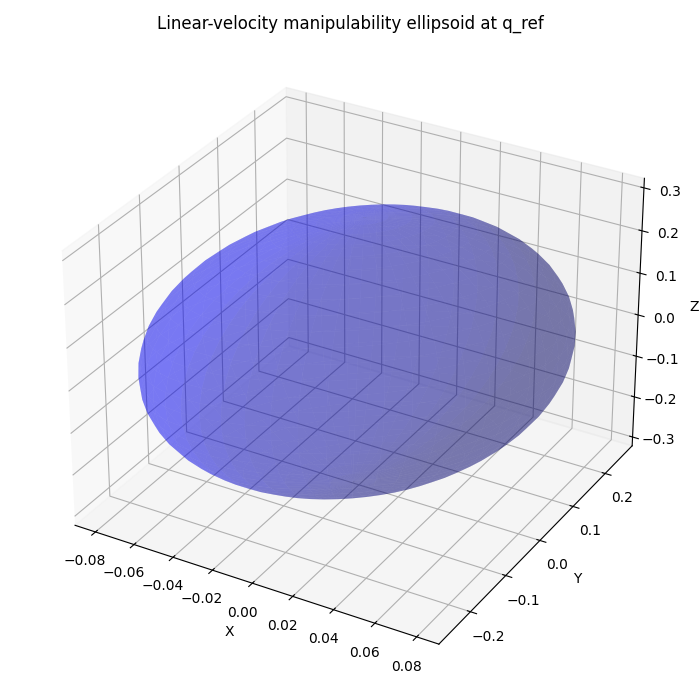

In [37]:
Jv = J0[:3, :]  # linear velocity rows
A = Jv @ Jv.T

# Eigendecomposition for the ellipsoid axes
eigenvalues, eigenvectors = np.linalg.eigh(A)

# Generate unit sphere points
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 30)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))

# Transform sphere to ellipsoid
sphere_pts = np.stack([x_sphere.ravel(), y_sphere.ravel(), z_sphere.ravel()])
scale = np.diag(np.sqrt(np.maximum(eigenvalues, 0)))
ellipsoid_pts = eigenvectors @ scale @ sphere_pts

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(
    ellipsoid_pts[0].reshape(x_sphere.shape),
    ellipsoid_pts[1].reshape(y_sphere.shape),
    ellipsoid_pts[2].reshape(z_sphere.shape),
    alpha=0.3, color='b',
)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Linear-velocity manipulability ellipsoid at q_ref')
plt.tight_layout()

## Resolved-Rate Velocity Control

### 16. Simple resolved-rate integration

Integrate a constant desired Cartesian twist $\boldsymbol{v}_d$ into a joint-space trajectory using the resolved-rate equation with the Jacobian updated at each step:

$$\boldsymbol{q}_{k+1} = \boldsymbol{q}_k + \boldsymbol{J}(\boldsymbol{q}_k)^{-1} \, \boldsymbol{v}_d \, \Delta t$$

Start from the reference configuration and integrate for 2 seconds with $\Delta t = 0.05$ s. Track the end-effector position over time.

In [38]:
dt = 0.05
t_final = 2.0
t_vec = np.arange(0, t_final + dt, dt)

# Desired Cartesian twist: gentle linear motion in x and z
v_desired = np.array([0.02, 0.0, -0.01, 0.0, 0.0, 0.05])  # m/s, rad/s

q_traj = np.zeros((len(t_vec), mycobot.n))
ee_pos = np.zeros((len(t_vec), 3))
q_traj[0, :] = q_ref.copy()
ee_pos[0, :] = mycobot.fkine(q_ref, end=bodyname).A[:3, 3]

for k in range(len(t_vec) - 1):
    J_k = mycobot.jacob0(q_traj[k], end=bodyname)  # compute the base-frame Jacobian at the current trajectory point
    qdot_k = np.linalg.solve(J_k, v_desired)  # solve for the joint rates that produce the desired Cartesian twist

    q_traj[k + 1, :] = q_traj[k, :] + qdot_k * dt
    ee_pos[k + 1, :] = mycobot.fkine(q_traj[k + 1], end=bodyname).A[:3, 3]

### 17. Plot the resolved-rate trajectory

Plot the end-effector position over time and the joint angles over time.

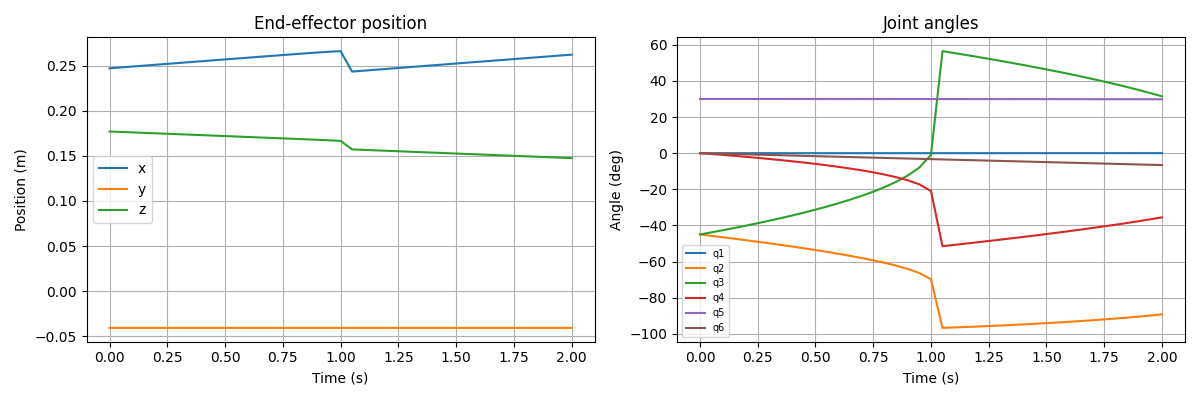

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_vec, ee_pos[:, 0], label='x')
axes[0].plot(t_vec, ee_pos[:, 1], label='y')
axes[0].plot(t_vec, ee_pos[:, 2], label='z')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (m)')
axes[0].set_title('End-effector position')
axes[0].legend()
axes[0].grid(True)

for j in range(mycobot.n):
    axes[1].plot(t_vec, np.degrees(q_traj[:, j]), label=f'q{j+1}')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Angle (deg)')
axes[1].set_title('Joint angles')
axes[1].legend(fontsize=7)
axes[1].grid(True)

plt.tight_layout()

### 18. Track manipulability along the trajectory

Compute and plot the Yoshikawa manipulability at each step of the resolved-rate trajectory. If the trajectory approaches a singularity, the manipulability will drop.

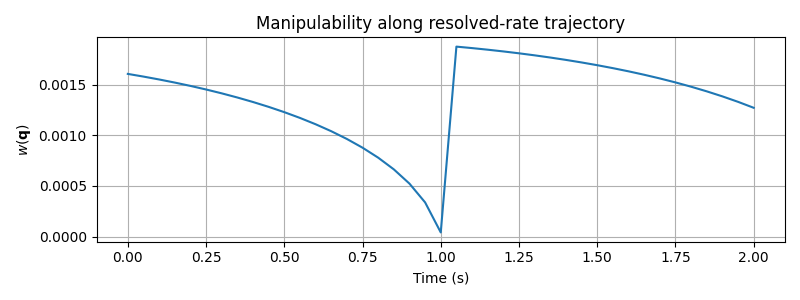

In [40]:
w_traj = np.zeros(len(t_vec))

for k in range(len(t_vec)):
    J_k = mycobot.jacob0(q_traj[k], end=bodyname)  # compute the base-frame Jacobian at the current trajectory point
    w_traj[k] = abs(np.linalg.det(J_k))  # compute the manipulability measure at this trajectory point

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_vec, w_traj)
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$w(\mathbf{q})$')
ax.set_title('Manipulability along resolved-rate trajectory')
ax.grid(True)
plt.tight_layout()

## Bridge to the Live Controller

### 19. Velocity control via `/mycobot/joint_velocity`

The myCobot 280 controller accepts joint velocity commands on the `/mycobot/joint_velocity` topic as a `std_msgs/msg/Float64MultiArray` with 6 values in **rad/s**.

Key controller behaviour (from the codebase):
- **Deadband:** velocities below `0.01 rad/s` per joint are treated as zero.
- **Max speed:** mapped from `150 deg/s` (~2.618 rad/s) at speed level 100.
- **Acceleration ramp:** limited to `1.0 rad/s²` to smooth sudden velocity changes.
- **Stop on zero:** sending an all-zero velocity vector triggers a stop command.
- The controller integrates velocities into angle targets at 20 Hz (`cmd_tick_hz`) and streams angle commands to the hardware via the serial interface.

Compute a resolved-rate joint velocity for a short desired Cartesian twist at the current robot configuration and publish it. Ensure the `mycobot_control` launch is running in a separate terminal.

In [41]:
import time
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import JointState
from std_msgs.msg import Float64MultiArray

if not rclpy.ok():
    rclpy.init(args=None)


class JacobianVelocityNode(Node):
    def __init__(self):
        super().__init__('jacobian_lab_node')
        self.vel_pub = self.create_publisher(Float64MultiArray, '/mycobot/joint_velocity', 10)
        self.last_js = None
        self.js_sub = self.create_subscription(
            JointState, '/mycobot/joint_states', self._js_cb, 10,
        )

    def _js_cb(self, msg):
        self.last_js = msg

    def publish_velocity(self, qdot):
        msg = Float64MultiArray()
        msg.data = np.clip(qdot, -2.6, 2.6).tolist()  # stay within max speed
        self.vel_pub.publish(msg)

    def stop(self):
        msg = Float64MultiArray()
        msg.data = [0.0] * 6
        self.vel_pub.publish(msg)


vel_node = JacobianVelocityNode()

[WARN] [1790759579.140055117] [rcl.logging_rosout]: Publisher already registered for node name: 'jacobian_lab_node'. If this is due to multiple nodes with the same name then all logs for the logger named 'jacobian_lab_node' will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.


### 20. Send a resolved-rate velocity command

Read the current joint state, compute the Jacobian at the current configuration, compute the resolved-rate velocity for a gentle desired twist, publish it briefly, then stop.

In [42]:
# Read current joint state
rclpy.spin_once(vel_node, timeout_sec=1.0)

if vel_node.last_js is not None:
    q_current = np.array(vel_node.last_js.position, dtype=float)
    print('Current q (rad):', q_current)

    # Compute Jacobian at current configuration
    J_current = mycobot.jacob0(q_current, end=bodyname)  # compute the base-frame Jacobian at the current robot configuration

    # Desired twist: gentle x-direction motion
    v_cmd = np.array([0.02, 0.0, 0.0, 0.0, 0.0, 0.0])

    # Resolved rate
    qdot_cmd = np.linalg.pinv(J_current) @ v_cmd  # compute the resolved-rate joint-velocity command

    print('Commanding qdot (rad/s):', qdot_cmd)

    # Publish for 2 seconds then stop
    duration = 2.0
    rate_hz = 20.0
    start = time.time()
    while time.time() - start < duration:
        vel_node.publish_velocity(qdot_cmd)
        rclpy.spin_once(vel_node, timeout_sec=0.0)
        time.sleep(1.0 / rate_hz)

    vel_node.stop()
    print('Stopped.')
else:
    print('No joint state received. Is the controller running?')

# Optional cleanup:
# vel_node.destroy_node()
# rclpy.shutdown()

No joint state received. Is the controller running?
